In [1]:
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
from MDAnalysis import transformations as trans
import pymbar.timeseries as timeseries
import MDAnalysis.analysis.dihedrals as dihedrals
import seaborn as sns

/apps/gent/RHEL9/cascadelake-ib/software/Biopython/1.85-foss-2025a/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
E

In [2]:
files= [("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep1.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep1.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep2.tpr", 
        "/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep2.xtc"), 
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep3.tpr",
        "/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep3.xtc")]

In [3]:
# function to get the COM of an atomgroup across the entire trajectory

def get_com(u, sel: str, sel2: str):
    com_arr = np.empty((u.trajectory.n_frames, 3))
    select_group1 = u.select_atoms(sel)
    select_group2 = u.select_atoms(sel2)
    for frame in u.trajectory:
        if not frame.frame %10:
            print(frame.frame)
        com_arr[frame.frame, :] = select_group1.center_of_mass(unwrap=True)-select_group2.center_of_mass() # remove PBCs
    return com_arr

In [4]:
NFP_com_all_reps_bdn = np.empty((3, 5001, 3))

for i, simulation in enumerate(files):
    topology, trajectory = simulation
    u = mda.Universe(topology, trajectory)
    print(u.trajectory)
    NFP_com_all_reps_bdn[i, :, :] = get_com(u, sel = "resname BDQ", sel2 = "resname POPE")

<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep1.xtc with 5001 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990
1000
1010
1020
1030
1040
1050
1060
1070
1080
1090
1100
1110
1120
1130
1140
1150
1160
1170
1180
1190
1200
1210
1220
1230
1240
1250
1260
1270
1280
1290
1300
1310
1320
1330
1340
1350
1360
1370
1380
1390
1400
1410
1420
1430
1440
1450
1460
1470
1480
1490
1500
1510
1520
1530
1540
1550
1560
1570
1580
1590
1600
1610
1620
1630
1640
1650
1660
1670
1680
1690
1700
1710
1720
1730
1740
1750
1760
1770
1780
1790
1800
1810
1820
1830
1840
1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
19

In [5]:
files2= [("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/step7_production_rep1.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/BDN_rep1.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/step7_production_rep2.tpr", 
        "/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/BDN_rep2.xtc"), 
        ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/step7_production_rep3.tpr",
        "/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/BDN_rep3.xtc")]

In [6]:
NFP_com_all_reps_bdq = np.empty((3, 5001, 3))

for i, simulation in enumerate(files2):
    topology, trajectory = simulation
    u = mda.Universe(topology, trajectory)
    print(u.trajectory)
    NFP_com_all_reps_bdq[i, :, :] = get_com(u, sel = "resname BDN", sel2 = "resname POPE")

<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/BDN_rep1.xtc with 5001 frames of 43973 atoms>
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990
1000
1010
1020
1030
1040
1050
1060
1070
1080
1090
1100
1110
1120
1130
1140
1150
1160
1170
1180
1190
1200
1210
1220
1230
1240
1250
1260
1270
1280
1290
1300
1310
1320
1330
1340
1350
1360
1370
1380
1390
1400
1410
1420
1430
1440
1450
1460
1470
1480
1490
1500
1510
1520
1530
1540
1550
1560
1570
1580
1590
1600
1610
1620
1630
1640
1650
1660
1670
1680
1690
1700
1710
1720
1730
1740
1750
1760
1770
1780
1790
1800
1810
1820
1830
1840
1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
1950
1960
1970
1980
1990


In [8]:
ethanolamine = "resname POPE and (name C11-12 or name N or name O12)"
phosphate = "name P"
glycerol = "name O11 or name C1-C3 or name O21 or name O31"
tails = """name C22 or name C23 or name C24 or name C25 or name C26 or name C27 or name C28 or name C29 or name C210 or name C211 or name C212 or name C213 or name C214 or name C215 or name C216 or name C217 or name C218 or name C31 or name C32 or name C33 or name C34 or name C35 or name C36 or name C37 or name C38 or name C39 or name C310 or name C311 or name C312 or name C313 or name C314 or name C315 or name C316"""

In [9]:
u= mda.Universe(*files[0])
u.select_atoms(phosphoethanolamine).write("lipid_groups.ndx", name="choline", mode="w")
u.select_atoms(phosphate).write("lipid_groups.ndx", name="phosphate", mode="a")
u.select_atoms(glycerol).write("lipid_groups.ndx", name="glycerol", mode="a")
u.select_atoms(tails).write("lipid_groups.ndx", name="tails", mode="a")
u.select_atoms(f"{choline} or {phosphate}").write("lipid_groups.ndx", name="phosphocholine", mode="a")
u.select_atoms(f"resname TIP3").write("lipid_groups.ndx", name="water", mode="a")

NameError: name 'phosphoethanolamine' is not defined

In [8]:
phosphoethanolamine = np.loadtxt("phosphoethanolamine_density.xvg", comments=["#", "@"])
glycerol = np.loadtxt("glycerol.xvg", comments=["#", "@"])
tails = np.loadtxt("tails.xvg", comments=["#", "@"])
water = np.loadtxt("/scratch/gent/vo/000/gvo00003/vsc48847/apo_protein/charmm-gui-7064934746/gromacs/Rep1/water.xvg", comments=["#", "@"])

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Kleuren voor replicaten
rep_colors = ["#a1d99b", "#7fcdbb", "#2c7fb8"]

# Lipid info
names = ["Phosphoethanolamine", "Glycerol", "acyl", "water"]
lipidcolors = ["tomato", "green", "grey", "dodgerblue"]

# tijdas maken
n_frames = NFP_com_all_reps_bdq.shape[1]
time_ns = np.arange(n_frames) / 10

# figure
fig, ax = plt.subplots(1, 3, figsize=(14,5), gridspec_kw={'width_ratios':[1,1,1.2]})

# BDQ
for i in range(3):
    ax[0].plot(time_ns, NFP_com_all_reps_bdq[i, :, 2]/10, '.', markersize=1,
               label=f'replicate {i+1}', color=rep_colors[i])

ax[0].set_xlabel("Time (ns)")
ax[0].set_ylabel("Z axis position (nm)")
ax[0].set_ylim(-5,5)
ax[0].legend(markerscale=5, loc='upper center', bbox_to_anchor=(0.5,-0.25), ncol=3)
ax[0].set_title("BDN", fontsize=14)

# BDN
for i in range(3):
    ax[1].plot(time_ns, NFP_com_all_reps_bdn[i, :, 2]/10, '.', markersize=1,
               label=f'replicate {i+1}', color=rep_colors[i])

ax[1].set_xlabel("Time (ns)")
ax[1].set_ylabel("Z axis position (nm)")
ax[1].set_ylim(-5,5)
ax[1].legend(markerscale=5, loc='upper center', bbox_to_anchor=(0.5,-0.25), ncol=3)
ax[1].set_title("BDP", fontsize=14)

# density
for i, group in enumerate((phosphoethanolamine, glycerol, tails, water)):
    ax[2].plot(group[:,1], group[:,0]-np.mean(group[:,0]),
               label=names[i], color=lipidcolors[i])

ax[2].set_xlabel("Density (kg/m$^3$)")
ax[2].set_ylim(-5,5)
ax[2].legend(loc='upper center', bbox_to_anchor=(0.5,-0.25), ncol=4)
ax[2].set_title("Lipid Density", fontsize=14)

plt.tight_layout()
plt.savefig("lipid_plots.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
nfp_traj = mda.Universe("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep1.tpr", "/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep1.xtc")

In [5]:
dihedral_atoms = nfp_traj.select_atoms("resname BDQ and (name C10 or name C07 or name C06 or name C09)")
print(len(dihedral_atoms))
ring_dihedral = dihedrals.Dihedral([dihedral_atoms, ]).run()
ring_dihedral.angles
ring_dihedral = ring_dihedral.angles

4


/apps/gent/RHEL9/cascadelake-ib/software/MDAnalysis/2.9.0-foss-2025a/lib/python3.13/site-packages/MDAnalysis/analysis/dihedrals.py:337: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


/tmp/ipykernel_734245/1932702605.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


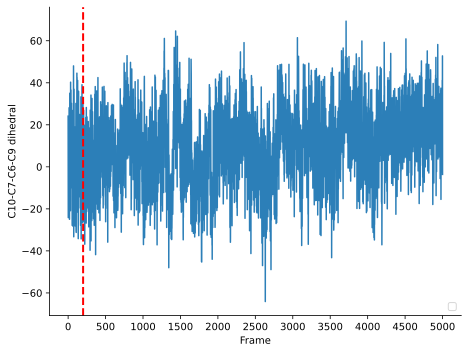

In [6]:
fig, ax = plt.subplots()

ax.plot(ring_dihedral, color="#2c7fb8")

# rode verticale lijn bij x = 200
ax.axvline(x=200, color='red', linestyle='--', linewidth=2)

ax.set_xticks(np.arange(0, 5001, 500))
ax.set_xlabel("Frame")
ax.set_ylabel("C10-C7-C6-C9 dihedral")
ax.legend(loc="lower right")

plt.savefig("BDQ_dihedral1_time.pdf")

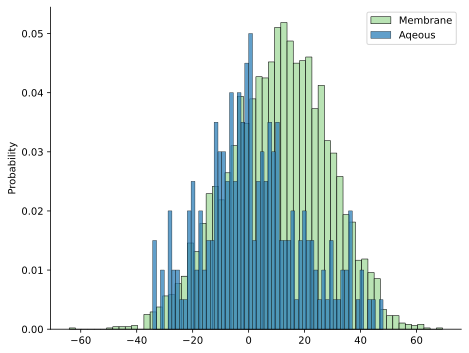

In [7]:
membrane = ring_dihedral[200: ].squeeze()
aq = ring_dihedral[:200].squeeze()

fig, ax = plt.subplots()
sns.histplot(membrane, 
             color = ( "#a1d99b"),
             label = "Membrane", bins = 60, kde=False, stat = "probability")
sns.histplot(aq, 
        color =  ("#2c7fb8"), 
       label = "Aqeous", bins = 60, kde=False, stat = "probability")
ax.legend()
plt.savefig("BDQ_10_7_6_9.png")

/tmp/ipykernel_2473799/1773416243.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


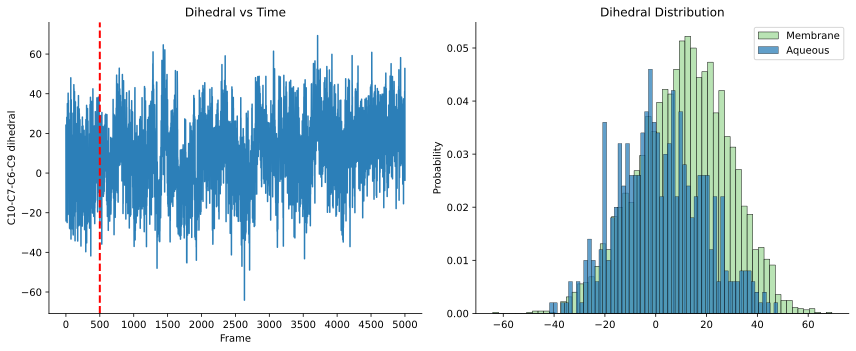

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Plot 1: tijdsverloop ----
axes[0].plot(ring_dihedral, color="#2c7fb8")
axes[0].axvline(x=500, color='red', linestyle='--', linewidth=2)
axes[0].set_xticks(np.arange(0, 5001, 500))
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("C10-C7-C6-C9 dihedral")
axes[0].set_title("Dihedral vs Time")

# ---- Data splitsen ----
membrane = ring_dihedral[500:].squeeze()
aq = ring_dihedral[:500].squeeze()

# ---- Plot 2: histogram ----
sns.histplot(membrane, 
             color="#a1d99b",
             label="Membrane",
             bins=60,
             kde=False,
             stat="probability",
             ax=axes[1])

sns.histplot(aq, 
             color="#2c7fb8",
             label="Aqueous",
             bins=60,
             kde=False,
             stat="probability",
             ax=axes[1])

axes[1].set_title("Dihedral Distribution")
axes[1].legend()

# ---- Layout en opslaan ----
plt.tight_layout()
plt.savefig("BDQ_combined.png", dpi=300)
plt.show()

In [62]:
dihedral_atoms = nfp_traj.select_atoms("resname BDQ and (name C11 or name C08 or name C06 or name C07)")
print(len(dihedral_atoms))
ring_dihedral = dihedrals.Dihedral([dihedral_atoms, ]).run()
ring_dihedral.angles
ring_dihedral = ring_dihedral.angles

4


/apps/gent/RHEL9/cascadelake-ib/software/MDAnalysis/2.9.0-foss-2025a/lib/python3.13/site-packages/MDAnalysis/analysis/dihedrals.py:337: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


/tmp/ipykernel_2473799/970810646.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = "lower right")


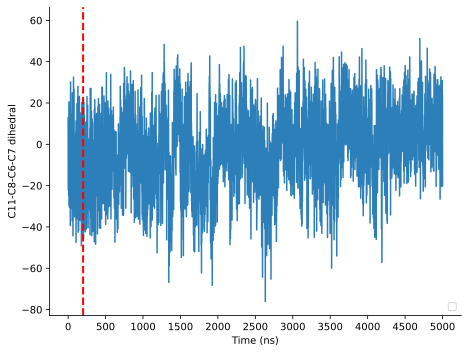

In [48]:
fig, ax = plt.subplots()
ax.plot(ring_dihedral, color = "#2c7fb8")
ax.axvline(x=200, color='red', linestyle='--', linewidth=2)
ax.set_xticks(np.arange(0, 5001, 500))
ax.set_xlabel("Time (ns)")
ax.set_ylabel("C11-C8-C6-C7 dihedral")
ax.legend(loc = "lower right")
plt.savefig("BDQ_dihedral2_time.pdf")

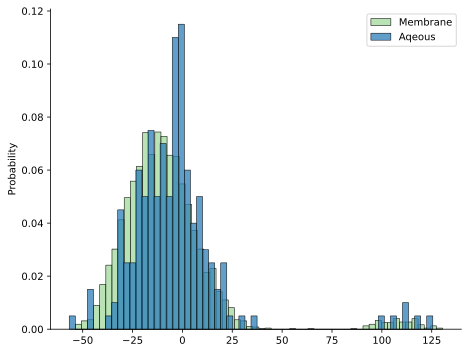

In [33]:
membrane = ring_dihedral[200: ].squeeze()
aq = ring_dihedral[:200].squeeze()

fig, ax = plt.subplots()
sns.histplot(membrane, 
             color = ( "#a1d99b"),
             label = "Membrane", bins = 60, kde=False, stat = "probability")
sns.histplot(aq, 
        color =  ("#2c7fb8"), 
       label = "Aqeous", bins = 60, kde=False, stat = "probability")
ax.legend()
plt.savefig("BDQ_dihedral2_memaq.pdf")

/tmp/ipykernel_2473799/326134730.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


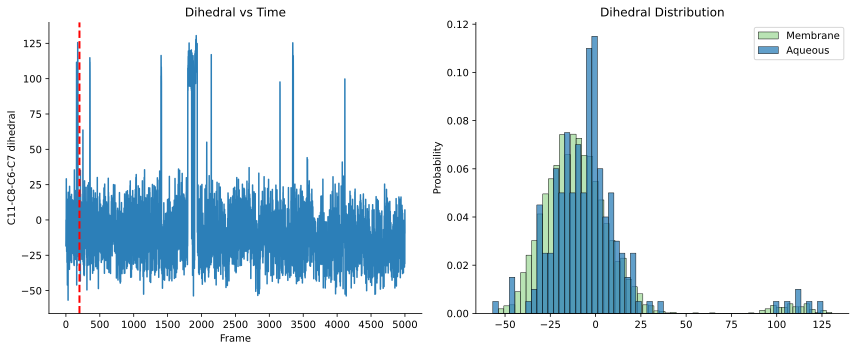

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Plot 1: tijdsverloop ----
axes[0].plot(ring_dihedral, color="#2c7fb8")
axes[0].axvline(x=200, color='red', linestyle='--', linewidth=2)
axes[0].set_xticks(np.arange(0, 5001, 500))
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("C11-C8-C6-C7 dihedral")
axes[0].set_title("Dihedral vs Time")

# ---- Data splitsen ----
membrane = ring_dihedral[200:].squeeze()
aq = ring_dihedral[:200].squeeze()

# ---- Plot 2: histogram ----
sns.histplot(membrane, 
             color="#a1d99b",
             label="Membrane",
             bins=60,
             kde=False,
             stat="probability",
             ax=axes[1])

sns.histplot(aq, 
             color="#2c7fb8",
             label="Aqueous",
             bins=60,
             kde=False,
             stat="probability",
             ax=axes[1])

axes[1].set_title("Dihedral Distribution")
axes[1].legend()

# ---- Layout en opslaan ----
plt.tight_layout()
plt.savefig("BDQ_combined_dihedral2.png", dpi=300)
plt.show()

In [8]:
dihedral_atoms = nfp_traj.select_atoms("resname BDQ and (name C08 or name C06 or name C07 or name C12)")
print(len(dihedral_atoms))
ring_dihedral = dihedrals.Dihedral([dihedral_atoms, ]).run()
ring_dihedral.angles
ring_dihedral = ring_dihedral.angles

4


/apps/gent/RHEL9/cascadelake-ib/software/MDAnalysis/2.9.0-foss-2025a/lib/python3.13/site-packages/MDAnalysis/analysis/dihedrals.py:337: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


/tmp/ipykernel_2473799/3847518135.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = "lower right")


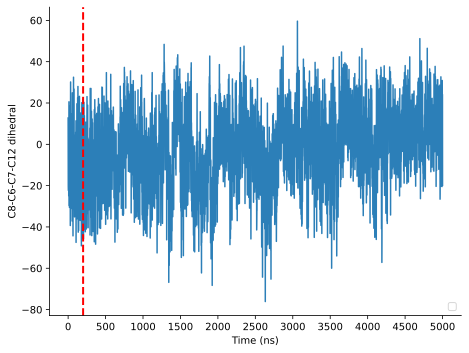

In [52]:
fig, ax = plt.subplots()
ax.plot(ring_dihedral, color = "#2c7fb8")
ax.axvline(x=200, color='red', linestyle='--', linewidth=2)
ax.set_xticks(np.arange(0, 5001, 500))
ax.set_xlabel("Time (ns)")
ax.set_ylabel("C8-C6-C7-C12 dihedral")
ax.legend(loc = "lower right")
plt.savefig("BDQ_dihedral3_time.pdf")

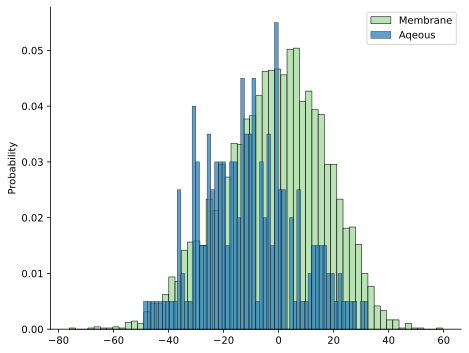

In [9]:
membrane = ring_dihedral[200: ].squeeze()
aq = ring_dihedral[:200].squeeze()

fig, ax = plt.subplots()
sns.histplot(membrane, 
             color = ( "#a1d99b"),
             label = "Membrane", bins = 60, kde=False, stat = "probability")
sns.histplot(aq, 
        color =  ("#2c7fb8"), 
       label = "Aqeous", bins = 60, kde=False, stat = "probability")
ax.legend()
plt.savefig("BDQ_dihedral3_memaq.png")

/tmp/ipykernel_2473799/3817744519.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


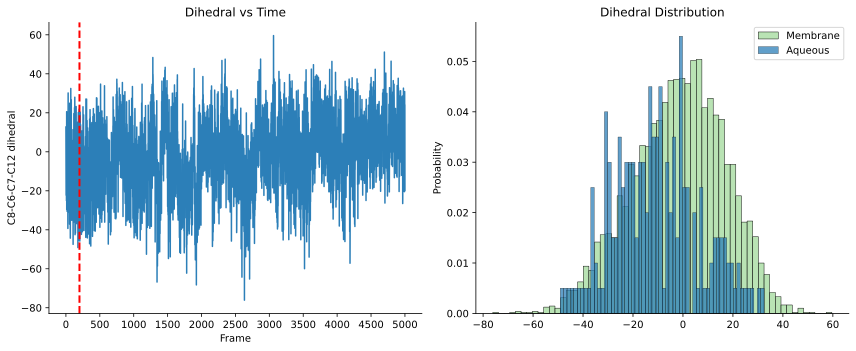

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Plot 1: tijdsverloop ----
axes[0].plot(ring_dihedral, color="#2c7fb8")
axes[0].axvline(x=200, color='red', linestyle='--', linewidth=2)
axes[0].set_xticks(np.arange(0, 5001, 500))
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("C8-C6-C7-C12 dihedral")
axes[0].set_title("Dihedral vs Time")

# ---- Data splitsen ----
membrane = ring_dihedral[200:].squeeze()
aq = ring_dihedral[:200].squeeze()

# ---- Plot 2: histogram ----
sns.histplot(membrane, 
             color="#a1d99b",
             label="Membrane",
             bins=60,
             kde=False,
             stat="probability",
             ax=axes[1])

sns.histplot(aq, 
             color="#2c7fb8",
             label="Aqueous",
             bins=60,
             kde=False,
             stat="probability",
             ax=axes[1])

axes[1].set_title("Dihedral Distribution")
axes[1].legend()

# ---- Layout en opslaan ----
plt.tight_layout()
plt.savefig("BDQ_combined.png", dpi=300)
plt.show()

In [3]:
u1 = mda.Universe("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep1.tpr", "/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep1.xtc")
com_arr = np.ndarray((5001, 1))
sel_bdq = u1.select_atoms("resname BDQ")
sel_pope = u1.select_atoms("name P")
for frame in u1.trajectory:
    if not frame.frame % 500: print(frame.frame)
    dist = sel_bdq.center_of_mass(unwrap=True)[2] - sel_pope.center_of_mass()[2]
    com_arr[frame.frame] = dist

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000


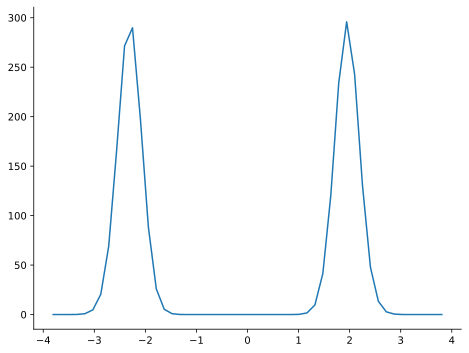

In [47]:
plt.plot(phosphoethanolamine[:, 0]-np.mean(phosphoethanolamine[:, 0]), phosphoethanolamine[:, 1])

In [48]:
# placing the barrier at d=20 is somewhat arbitrary without knowing 
inside = com_arr[(com_arr<20) & (com_arr >-20)]

print("Mean: ", np.mean(inside))
print("SEM: ", np.sqrt(np.std(inside)/(timeseries.statistical_inefficiency(inside)-1)))

Mean:  15.27518233637677
SEM:  0.15979381491529096


In [4]:
# placing the barrier at d=20 is somewhat arbitrary without knowing 
inside = com_arr[(com_arr < 20) & (com_arr > -20)]

inside_abs = np.abs(inside)

print("Mean: ", np.mean(inside_abs))
print("SEM: ", np.sqrt(np.std(inside_abs) / (timeseries.statistical_inefficiency(inside_abs) - 1)))

Mean:  15.27518233637677
SEM:  0.15979381491529096


In [41]:
u2 = mda.Universe("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep2.tpr", "/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep2.xtc")
com_arr = np.ndarray((5001, 1))
sel_bdq = u2.select_atoms("resname BDQ")
sel_pope = u2.select_atoms("name P")
for frame in u2.trajectory:
    if not frame.frame % 500: print(frame.frame)
    dist = sel_bdq.center_of_mass(unwrap=True)[2] - sel_pope.center_of_mass()[2]
    com_arr[frame.frame] = dist

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000


In [42]:
# placing the barrier at d=20 is somewhat arbitrary without knowing 
inside = abs(com_arr[(com_arr<20) & (com_arr >-20)])

print("Mean: ", np.mean(inside))
print("SEM: ", np.sqrt(np.std(inside)/(timeseries.statistical_inefficiency(inside)-1)))

Mean:  15.153279140525823
SEM:  0.17391921109740377


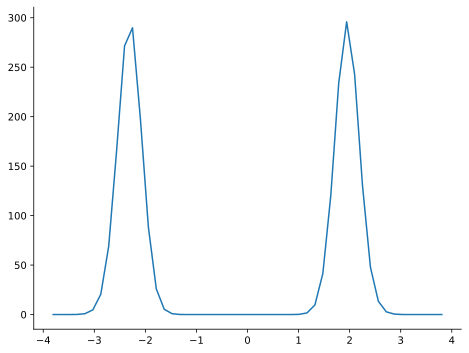

In [43]:
plt.plot(phosphoethanolamine[:, 0]-np.mean(phosphoethanolamine[:, 0]), phosphoethanolamine[:, 1])

In [49]:
u3 = mda.Universe("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep3.tpr", "/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/step7_production_rep3.xtc")
com_arr = np.ndarray((5001, 1))
sel_bdq = u3.select_atoms("resname BDQ")
sel_pope = u3.select_atoms("name P")
for frame in u3.trajectory:
    if not frame.frame % 500: print(frame.frame)
    dist = sel_bdq.center_of_mass(unwrap=True)[2] - sel_pope.center_of_mass()[2]
    com_arr[frame.frame] = dist

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000


In [50]:
# placing the barrier at d=20 is somewhat arbitrary without knowing 
inside = abs(com_arr[(com_arr<20) & (com_arr >-20)])

print("Mean: ", np.mean(inside))
print("SEM: ", np.sqrt(np.std(inside)/(timeseries.statistical_inefficiency(inside)-1)))

Mean:  15.619056785616054
SEM:  0.20658334071271653


In [2]:
files= [("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_6/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_6/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_7/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_7/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_8/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_8/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_9/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_9/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_10/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_10/topol.xtc"),]

In [8]:
NFP_com_all_reps = np.empty((10, 101, 3))

for i, simulation in enumerate(files):
    topology, trajectory = simulation
    u = mda.Universe(topology, trajectory)
    print(u.trajectory)
    NFP_com_all_reps[i, :, :] = get_com(u, sel = "resname BDQ", sel2 = "resname POPE")

<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_

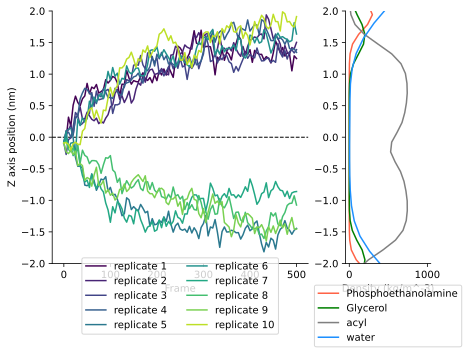

In [20]:
names = ["Phosphoethanolamine", "Glycerol", "acyl", "water"]
lipidcolors = ["tomato", "green", "grey", "dodgerblue"]

fig, ax = plt.subplots(1, 2, width_ratios=[3, 1])

for i, group in enumerate((phosphoethanolamine, glycerol, tails, water)):
    ax[1].plot(group[:, 1], group[:, 0]-np.mean(group[:, 0]), label=names[i], color=lipidcolors[i])

ax[0].set_ylim(-2, 2)
ax[1].set_ylim(-2, 2)
ax[0].axhline(y=0, color='black', linestyle='--', linewidth=1)

ax[0].set_xticks(np.arange(0, 101, 20), np.arange(0, 501, 100))

ax[1].set_xlabel("Density (kg/m^-3)")

for i in range(10):
    ax[0].plot(NFP_com_all_reps[i, :, 2]/10, linestyle='-', markersize=1, label=f'replicate {i + 1}', color=plt.cm.viridis(i/10), rasterized=False)

ax[0].set_xlabel("Frame")
ax[0].set_ylabel("Z axis position (nm)")
ax[0].legend(markerscale=10, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)
ax[1].legend(markerscale=10, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=1)
ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)

In [6]:
import numpy as np

target_angle = 20
tolerance = 1   # graden

frames = np.where(np.abs(ring_dihedral - target_angle) < tolerance)[0]

print("Frames waar dihedral ~0°:", frames)

Frames waar dihedral ~0°: [   7   74   76   90  120  178  211  217  251  300  324  350  364  410
  420  439  456  460  477  493  530  534  546  559  599  708  752  758
  791  812  830  851  887  905  908  972 1039 1117 1138 1153 1162 1268
 1270 1333 1421 1423 1438 1451 1473 1480 1492 1498 1519 1551 1562 1606
 1852 1880 1901 1957 1994 2023 2038 2066 2131 2132 2194 2201 2222 2274
 2326 2433 2488 2507 2528 2786 2806 2851 2852 2864 2874 2878 2879 2894
 2895 2899 2932 2955 2958 2962 2980 3031 3036 3040 3051 3105 3143 3157
 3215 3221 3239 3257 3299 3304 3316 3338 3339 3340 3367 3435 3438 3448
 3488 3500 3506 3555 3567 3613 3615 3631 3658 3662 3664 3683 3692 3699
 3702 3707 3730 3739 3758 3777 3790 3806 3829 3911 3917 3918 3962 3966
 3981 3984 4000 4019 4046 4107 4119 4165 4172 4197 4249 4250 4264 4291
 4296 4305 4313 4379 4385 4400 4474 4488 4536 4538 4548 4557 4558 4575
 4584 4586 4617 4643 4668 4687 4753 4754 4768 4775 4789 4799 4804 4810
 4829 4873 4881 4907 4921 4925 4983 4994]


Atoms dihedral 1: 4
Atoms dihedral 2: 4


/tmp/ipykernel_3295380/2182270270.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


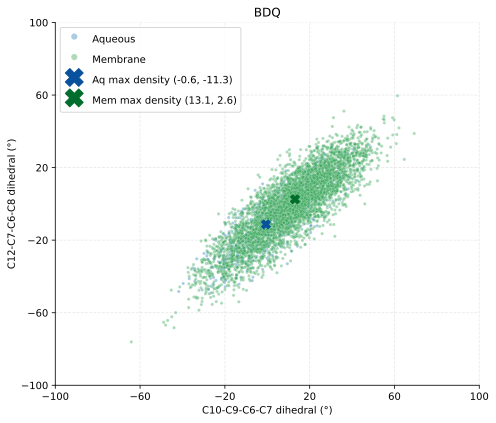

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
# ---- Definieer dihedral 1 ----
dihedral_atoms1 = nfp_traj.select_atoms(
    "resname BDQ and (name C10 or name C09 or name C06 or name C07)"
)
print("Atoms dihedral 1:", len(dihedral_atoms1))

# ---- Definieer dihedral 2 ----
dihedral_atoms2 = nfp_traj.select_atoms(
    "resname BDQ and (name C12 or name C07 or name C06 or name C08)"
)
print("Atoms dihedral 2:", len(dihedral_atoms2))


# ---- Bereken dihedralen ----
ring_dihedral1 = dihedrals.Dihedral([dihedral_atoms1]).run()
ring_dihedral2 = dihedrals.Dihedral([dihedral_atoms2]).run()

# ---- Flatten dihedral arrays ----
dih1 = ring_dihedral1.angles.flatten()  # C10-C9-C6-C7
dih2 = ring_dihedral2.angles.flatten()  # C12-C7-C6-C8

# ---- Split frames into aqueous vs membrane ----
split_frame = 500  # frames before penetration = aqueous
aq_dih1 = dih1[:split_frame]
aq_dih2 = dih2[:split_frame]
mem_dih1 = dih1[split_frame:]
mem_dih2 = dih2[split_frame:]

# ---- Function to find highest-density point ----
def get_max_density(x, y):
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    density = kde(values)
    idx_max = np.argmax(density)
    return x[idx_max], y[idx_max]

# Max density points
aq_xmax, aq_ymax = get_max_density(aq_dih1, aq_dih2)
mem_xmax, mem_ymax = get_max_density(mem_dih1, mem_dih2)

# ---- Plot ----
plt.figure(figsize=(7,6))

# Scatter for aqueous
sns.scatterplot(x=aq_dih1, y=aq_dih2, color="#2c7fb8", alpha=0.4, s=10, label="Aqueous")

# Scatter for membrane
sns.scatterplot(x=mem_dih1, y=mem_dih2, color="#31a354", alpha=0.4, s=10, label="Membrane")

# Cross markers for highest intensity, label includes value
plt.scatter(aq_xmax, aq_ymax, color="#08519c", s=80, marker='X', 
            label=f"Aq max density ({aq_xmax:.1f}, {aq_ymax:.1f})")
plt.scatter(mem_xmax, mem_ymax, color="#006d2c", s=80, marker='X', 
            label=f"Mem max density ({mem_xmax:.1f}, {mem_ymax:.1f})")

# Axes settings: -100° to 100°
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.xticks(np.arange(-100, 101, 40))
plt.yticks(np.arange(-100, 101, 40))
plt.grid(True, linestyle="--", alpha=0.3)

# Labels and title
plt.xlabel("C10-C9-C6-C7 dihedral (°)")
plt.ylabel("C12-C7-C6-C8 dihedral (°)")
plt.title("BDQ")

# Legend with bigger markers
plt.legend(markerscale=2, handleheight=2)

plt.tight_layout()
plt.savefig("BDQ_dihedral_map_final_labels_legend.png", dpi=300)
plt.show()

In [8]:
import numpy as np

# --- Waarden van interesse (max density of gewenste hoeken) ---
target_aq = (aq_xmax, aq_ymax)
target_mem = (mem_xmax, mem_ymax)

# --- Tolerantie (pas aan indien nodig, bv ±5°) ---
tol = 1e-2

# --- Frames binnen de tolerantie en hun waarden ---

# Aqueous
frames_aq = np.where(
    (np.abs(dih1[:split_frame] - target_aq[0]) < tol) &
    (np.abs(dih2[:split_frame] - target_aq[1]) < tol)
)[0]
values_aq = np.vstack((dih1[frames_aq], dih2[frames_aq])).T  # kolommen = dihedral1, dihedral2

# Membrane
frames_mem = np.where(
    (np.abs(dih1[split_frame:] - target_mem[0]) < tol) &
    (np.abs(dih2[split_frame:] - target_mem[1]) < tol)
)[0] + split_frame
values_mem = np.vstack((dih1[frames_mem], dih2[frames_mem])).T

# Intersectie (frames in gehele traject die exact voldoen aan target_aq)
frames_total = np.where(
    (np.abs(dih1 - target_aq[0]) < tol) &
    (np.abs(dih2 - target_aq[1]) < tol)
)[0]
values_total = np.vstack((dih1[frames_total], dih2[frames_total])).T

# --- Output ---
print("Aqueous frames & values:")
for f, v in zip(frames_aq, values_aq):
    print(f"Frame {f}: Dihedral1 = {v[0]:.5f}, Dihedral2 = {v[1]:.5f}")

print("\nMembrane frames & values:")
for f, v in zip(frames_mem, values_mem):
    print(f"Frame {f}: Dihedral1 = {v[0]:.5f}, Dihedral2 = {v[1]:.5f}")

print("\nIntersectie frames & values (hele traject):")
for f, v in zip(frames_total, values_total):
    print(f"Frame {f}: Dihedral1 = {v[0]:.5f}, Dihedral2 = {v[1]:.5f}")

Aqueous frames & values:
Frame 88: Dihedral1 = -0.64565, Dihedral2 = -11.30326

Membrane frames & values:
Frame 2940: Dihedral1 = 13.06232, Dihedral2 = 2.55595

Intersectie frames & values (hele traject):
Frame 88: Dihedral1 = -0.64565, Dihedral2 = -11.30326


In [5]:
dihedral_atoms = nfp_traj.select_atoms("resname BDQ and (name C11 or name C08 or name C06 or name C09)")
print(len(dihedral_atoms))
ring_dihedral = dihedrals.Dihedral([dihedral_atoms, ]).run()
ring_dihedral.angles
ring_dihedral = ring_dihedral.angles

4


/apps/gent/RHEL9/cascadelake-ib/software/MDAnalysis/2.9.0-foss-2025a/lib/python3.13/site-packages/MDAnalysis/analysis/dihedrals.py:337: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


NameError: name 'plot' is not defined

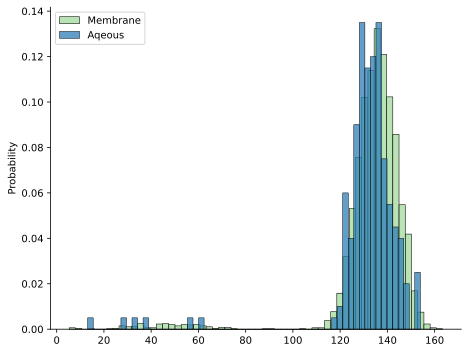

In [6]:
membrane = ring_dihedral[200: ].squeeze()
aq = ring_dihedral[:200].squeeze()

fig, ax = plt.subplots()
sns.histplot(membrane, 
             color = ( "#a1d99b"),
             label = "Membrane", bins = 60, kde=False, stat = "probability")
sns.histplot(aq, 
        color =  ("#2c7fb8"), 
       label = "Aqeous", bins = 60, kde=False, stat = "probability")
ax.legend()
plt.savefig("BDQ.pdf")
plot.show()